In [1]:
%matplotlib widget

import xbox_proc # Structure, DateRange
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nptdms import TdmsFile
from datetime import datetime

### Define structure

In [2]:
#keys = ["Timestamp", "Line 1 Pressure", "Line 2 Pressure", "DUT 1 Room Temp", "DUT 2 Room Temp", "Pulse Count 2", "Load 2 Pressure", "DUT 2 Pressure", "StructureBSurf_In Temp", "StructureBSurf_Out Temp", "StructureBWater_In Temp", "Load2 Temp", "DUT 2 Flow", "Pulse Count 1", "Load 1 Pressure", "DUT 1 Pressure", "DUT 1 Surf In Temp", "DUT 1 Surf Out Temp", "DUT 1 Water In Temp", "Load 1 RF In Temp", "DUT 1 Flow"]
keys = ["Timestamp", 'Klystron A Pressure', 'Hybrid 1 Pressure', 'Pulse Compressor 1 Pressure', 'Line 1 Pressure', "DUT 1 Pressure",'Load 1 Pressure',
        '1PKIA_ampcursor Blue mean ', '1PKIB_ampcursor Blue mean ', '1PLIA_ampcursor Blue mean ', '1PLIB_ampcursor Blue mean ', '1PSI_ampcursor grey mean ', 
        'Gauge Klystron A Pressure', 'Gauge PC 1 Pressure', 'Gauge Line 1 Pressure',  'Gauge Load 1 Pressure', 'Gauge Klystron B Pressure', 'Gauge DUT 1 Pressure',
        'Repetition rate']

s = xbox_proc.Structure(
    name="Xbox3_TD26CIEMAT_L1",
    data_dir="//cernbox-drive/winspaces/x/xboxes/Xbox3_TD26CIEMAT_L1",
    xbox=3,
    stand=1,
   
    P_ref = 42.3,  # [MW]
    G_ref = 100,  # MV/m
    t_fill=57.25e-9,
    
    BDR_ref=1.7e-6,
    PL_ref=180, # ns

    trend_keys=keys
    )

### Define data range

In [3]:
dr = xbox_proc.DateRange(20260301, 20260505)

### Extract data from tdms file to h5

In [4]:
trend_df = s.extract_trends(
    dr,
    out_h5="../data/TD26CIEMAT_L1_trend_data.h5",
    key="trend_data",
    mode="w"
)

trend_df.head()

,Timestamp,Klystron A Pressure,Hybrid 1 Pressure,Pulse Compressor 1 Pressure,Line 1 Pressure,Load 1 Pressure,DUT 1 Pressure,1PKIA_ampcursor Blue mean,1PKIB_ampcursor Blue mean,1PLIA_ampcursor Blue mean,1PLIB_ampcursor Blue mean,1PSI_ampcursor grey mean,Repetition rate
0,2026-03-01 00:00:00.180272579,1.973091e-09,1.591382e-09,1.430690e-08,1.717612e-09,3.839007e-08,2.809647e-09,269855.514032,269599.787577,462909.980469,278726.489058,1.768579e+06,200.000800
1,2026-03-01 00:00:01.180199146,1.970913e-09,1.595836e-09,1.432269e-08,1.729631e-09,3.840087e-08,2.813075e-09,269855.514032,269599.787577,462909.980469,278726.489058,1.768579e+06,200.000800
2,2026-03-01 00:00:02.180271149,1.970961e-09,1.591989e-09,1.427852e-08,1.742200e-09,3.841940e-08,2.801354e-09,269855.514032,269599.787577,462909.980469,278726.489058,1.768579e+06,199.981202
3,2026-03-01 00:00:03.180342197,1.970216e-09,1.605012e-09,1.430166e-08,1.727883e-09,3.845672e-08,2.798112e-09,269855.514032,269599.787577,462909.980469,278726.489058,1.768579e+06,199.908842
4,2026-03-01 00:00:04.181272984,1.972964e-09,1.605294e-09,1.429761e-08,1.720840e-09,3.840501e-08,2.803447e-09,271234.785540,270106.573307,464295.921870,278533.136621,1.771352e+06,200.415662


### Load data from h5

In [ ]:
s.load(path="../data/TD26CIEMAT_L1_trend_data.h5", key="trend_data")
df_trend = s.df

df_trend.head()
df_trend.tail()

### Example plotting

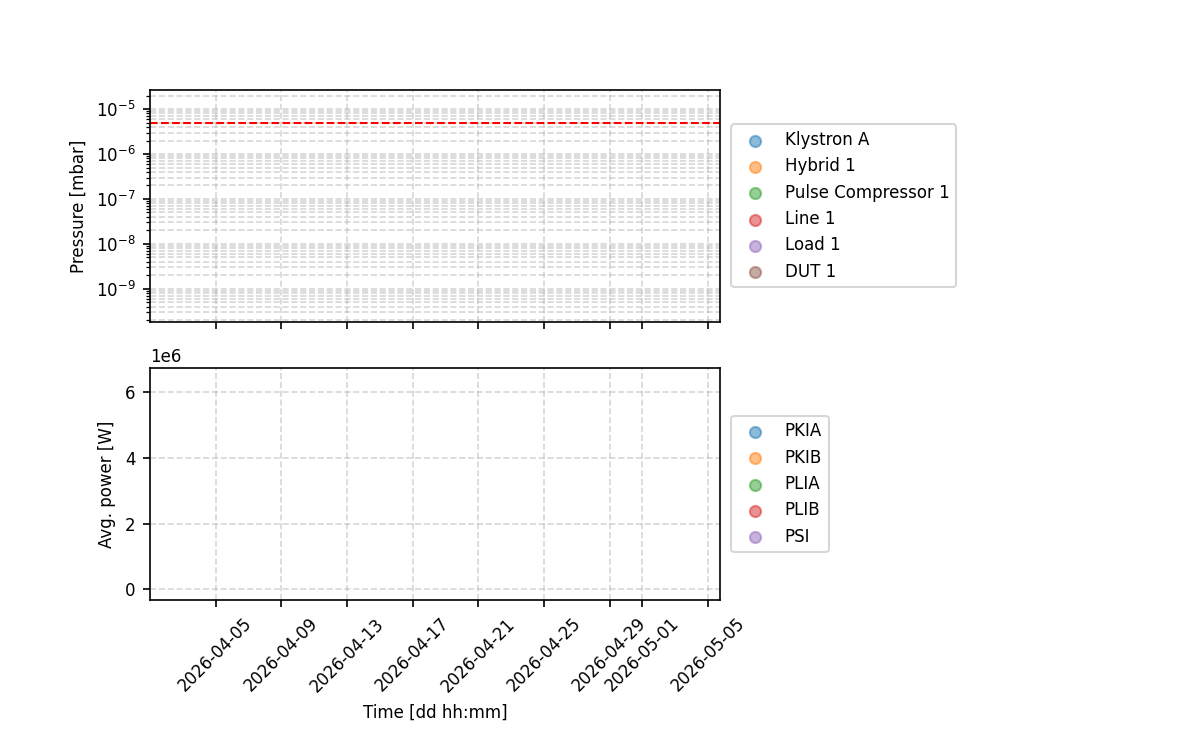

In [6]:
plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 10,
    'legend.fontsize': 8,
    'lines.linewidth': 1})

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True, dpi=150)

plot_keys_trend = ['Klystron A Pressure', 'Hybrid 1 Pressure', 'Pulse Compressor 1 Pressure', 'Line 1 Pressure', 'Load 1 Pressure', 'DUT 1 Pressure']
labels_trend = ['Klystron A', 'Hybrid 1', 'Pulse Compressor 1', 'Line 1', 'Load 1', 'DUT 1']
plot_keys_power = ['1PKIA_ampcursor Blue mean ', '1PKIB_ampcursor Blue mean ', '1PLIA_ampcursor Blue mean ', '1PLIB_ampcursor Blue mean ', '1PSI_ampcursor grey mean ']
labels_power = ['PKIA', 'PKIB', 'PLIA', 'PLIB',  'PSI']

for idx, el in enumerate(plot_keys_trend):
    ax[0].scatter(df_trend['Timestamp'], df_trend[el], label=labels_trend[idx], s=0.8, alpha = 0.5)
ax[0].set_yscale('log')

for idx, el in enumerate(plot_keys_power):
    ax[1].scatter(df_trend['Timestamp'], df_trend[el], label=labels_power[idx], s=0.8, alpha = 0.5)

start = pd.Timestamp("2026-04-01 00:05:00")
end   = pd.Timestamp("2026-05-05 17:20:00")

for axs in ax:
    axs.set_xlim(start, end)


for axs in ax:
    axs.grid(True, which='both', linestyle='--', alpha=0.5)
    axs.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        markerscale=6
    )

ax[0].axhline(y=5e-6, color='r', linestyle='--', label='5e-6 mbar')
plt.setp(ax[-1].get_xticklabels(), rotation=45)

#ax[2].plot(df_trend['Timestamp'], df_trend['Repetition rate'])

ax[0].set_ylabel("Pressure [mbar]")
ax[1].set_ylabel("Avg. power [W]")
ax[1].set_xlabel("Time [dd hh:mm]")

# Make room on the right
fig.subplots_adjust(right=0.6, bottom=0.2)

# fig.set_tight_layout
# plt.savefig("../../20261912_1705_RepRate200Hz_Jumping_VacuumActivity.png", bbox_inches='tight', dpi=150)                            